# Step 2: Main notebook

In [ ]:
import geopandas as gpd
import pandas as pd
from functools import reduce
import osmnx as ox
from shapely.geometry import Point
from matplotlib import pyplot as plt

import os

from method_a_buffer import extract_buffer_feature
from method_b_catchment import extract_catchment_feature
from method_c_zonal import compute_zonal_stat
#from method_d_join import spatial_join_attribute

import geopandas as gpd
import folium
from folium import Choropleth, CircleMarker, GeoJson
import osmnx as ox

In [ ]:

# Load segments GeoDataFrame (with 'segment_id')
print("Loading pedestrian segments, replace file path -->")
file_path = '/Users/Helo/Documents/Action_situee/index-marchabilite-ge/Notebook/Step 1/Output'
segments_gdf = gpd.read_file(f"{file_path}/step1_pedestrian_segments.gpkg")


Loading pedestrian segments...


In [ ]:
# Load pedestrian network attributes
# From SITG (shp)
print("Loading pedestrian network attributes, replace file path -->")
file_path = '/Users/Helo/Documents/Action_situee/index-marchabilite-ge/Notebook/Step 2/Data/OTC_ACCIDENTS-SHP'

accidents = gpd.read_file(f"{file_path}/OTC_ACCIDENTS.shp")
#add other files here


Loading pedestrian network attributes...


In [25]:
# Load pedestrian network attributes
# From OSM

# Define the area (can be the city or the full canton boundary if you have it)
area_name = "Geneva, Switzerland"

# Load amenities GeoDataFrame from OSM
print("Loading amenities...")

tags = {
    "amenity": [
        "school", "university", "hospital", "clinic", "pharmacy",
        "restaurant", "cafe", "bar", "library", "bank", "post_office",
        "kindergarten", "theatre", "cinema", "place_of_worship"
    ]
}

# Download amenities
print(f"Fetching amenities for {area_name}")
amenities = ox.features_from_place(area_name, tags=tags)


Loading amenities...
Fetching amenities for Geneva, Switzerland


In [26]:
# ACCIDENTS
#Ensure both GeoDataFrames use the same CRS
accidents = accidents.to_crs(segments_gdf.crs)

# Extract features by method
print("Extracting buffer features...")

# Extract accidents count
# Filter accidents that involve pedestrians
accidents["has_pedestrian"] = accidents["PIETONS"] > 0

accidents_df = extract_buffer_feature(
    segments_gdf,
    accidents,
    feature_name="accidents",
    buffer_radius=50,
    how="sum",
    value_column="PIETONS"
)

# Merge back into main segments DataFrame
print("Merging accidents count with segments...")
segments_gdf = segments_gdf.merge(accidents_df, on="segment_id", how="left")

Extracting buffer features...
Merging accidents count with segments...


In [27]:
# PROXIMITY TO AMENITIES

# Keep only Points (many amenities are points)
amenities = amenities[amenities.geometry.type == "Point"]

# Ensure same CRS as segments_gdf
amenities = amenities.to_crs(segments_gdf.crs)

# optional: Filter amenities or assign custom values to each amenity type
#amenities['amenity'].value_counts()

amenities_df = extract_catchment_feature(
    segments_gdf=segments_gdf,
    points_gdf=amenities,
    buffer_radius=350,
    feature_name="amenities"
)

# Merge back into main segments DataFrame
print("Merging with segments_gdf...")
segments_gdf = segments_gdf.merge(amenities_df, on="segment_id", how="left")

Buffering 1209 features by 350m...
Extracting segment centroids...
Performing spatial join...
Counting overlaps...
Merging with segments_gdf...


<Axes: >

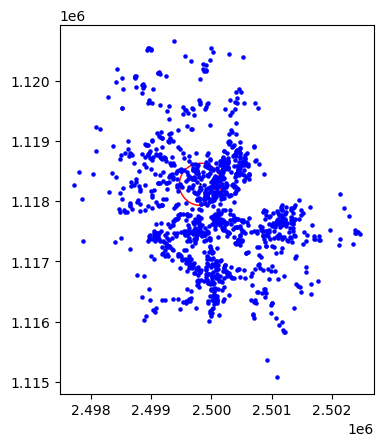

In [ ]:
#Check visually catchement count
'''
seg = segments_gdf[segments_gdf["segment_id"] == "000003"]
centroid = seg.geometry.iloc[0].interpolate(0.5, normalized=True)
buffer_geom = centroid.buffer(350)

# Wrap in a GeoSeries so we can plot it
buffer_gdf = gpd.GeoSeries([buffer_geom], crs=segments_gdf.crs)

# Plot everything
ax = buffer_gdf.plot(edgecolor="red", facecolor="none")
amenities.plot(ax=ax, color="blue", markersize=5)
seg.plot(ax=ax, color="black")
'''

(1117879.6155128088, 1118679.6155128088)

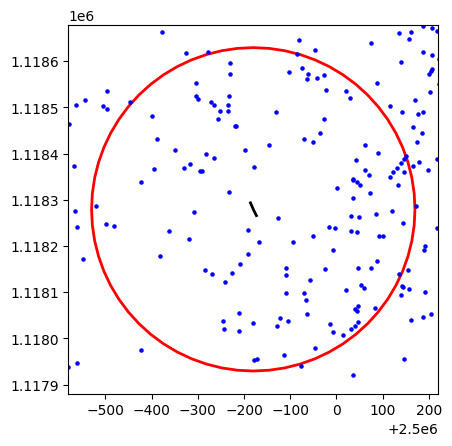

In [ ]:
# Zoom in to check visually catchement count
'''
ax = buffer_gdf.plot(edgecolor="red", facecolor="none", linewidth=2)
amenities.plot(ax=ax, color="blue", markersize=5)
seg.plot(ax=ax, color="black", linewidth=2)

# Zoom in: set limits around the buffer (with a margin)
buffer_bounds = buffer_geom.bounds  # (minx, miny, maxx, maxy)
margin = 50  # meters

ax.set_xlim(buffer_bounds[0] - margin, buffer_bounds[2] + margin)
ax.set_ylim(buffer_bounds[1] - margin, buffer_bounds[3] + margin)

'''

In [31]:
# Save final CSV
print("Saving features to CSV... ")
segments_gdf.to_csv("/Users/Helo/Documents/Action_situee/index-marchabilite-ge/Notebook/Step 2/Output/step2_features.csv", index=False)

Saving features to CSV... 
